cuda:2


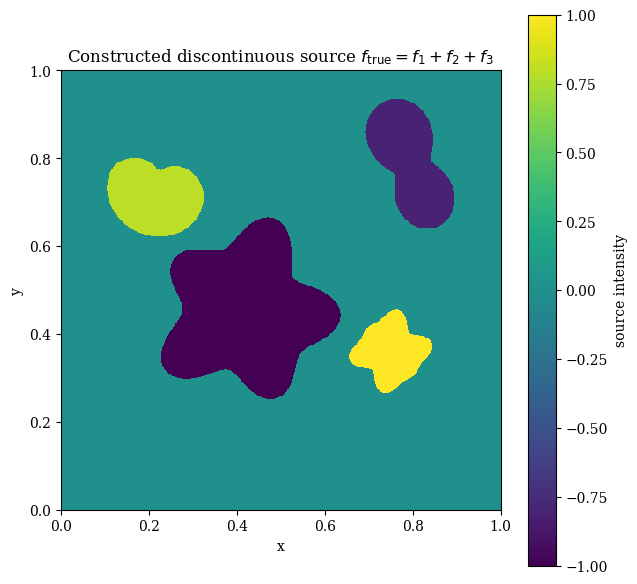

In [ ]:
from importlib import reload
import torch
import numpy as np
import time

torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(device)

import sys
sys.path.append(r"../main_code/2d")

import generate_data, mesh, adaptive_int, visual, matrix_assemble
import inverse_solver, mea_2d, net_2d, source_eval, error_general_2d, main
import matplotlib.pyplot as plt

CUDA_LAUNCH_BLOCKING = 1


def _composite_source_xy(X, Y):
    x1, y1 = 0.42, 0.45
    rho1 = np.sqrt((X - x1)**2 + (Y - y1)**2)
    theta1 = np.arctan2(Y - y1, X - x1)
    R1 = 0.18+ 0.035*np.cos(5*theta1) - 0.012*np.sin(3*theta1)
    f1 = -1.00 * (rho1 <= R1).astype(float)

    x2, y2 = 0.22, 0.76
    angle2 = -np.pi / 12.0   # 旋转一下方向，可自行调

    Xc2 = X - x2
    Yc2 = Y - y2
    Xp2 =  Xc2 * np.cos(angle2) + Yc2 * np.sin(angle2)
    Yp2 = -Xc2 * np.sin(angle2) + Yc2 * np.cos(angle2)

    rho2 = np.sqrt(Xp2**2 + Yp2**2)
    theta2 = np.arctan2(Yp2, Xp2)

    # 上窄下宽的水滴半径
    R2 = 0.08 * (1.1 - 0.8 * np.sin(theta2) + 0.2 * np.cos(1.8*theta2))
    R2 = np.maximum(R2, 0.015)
    f2 = 0.80 * (rho2 <= R2).astype(float)

    x3, y3 = 0.75, 0.36
    rho3 = np.sqrt((X - x3)**2 + (Y - y3)**2)
    theta3 = np.arctan2(Y - y3, X - x3)
    R3 = 0.08 + 0.012*np.cos(4*theta3) + 0.008*np.sin(6*theta3)
    f3 = 1* (rho3 <= R3).astype(float)

    # Component 4: leaf-shaped inclusion in the upper-right corner
    x4, y4 = 0.80, 0.78
    angle4 = np.pi / 8.0   # 叶子的朝向，可调

    Xc4 = X - x4
    Yc4 = Y - y4
    Xp4 =  Xc4 * np.cos(angle4) + Yc4 * np.sin(angle4)
    Yp4 = -Xc4 * np.sin(angle4) + Yc4 * np.cos(angle4)

    rho4 = np.sqrt(Xp4**2 + Yp4**2)
    theta4 = np.arctan2(Yp4, Xp4)

    # 叶片边界：左右两端更尖，中间更鼓
    R4 = 0.1* (1.0 - 0.55 * np.cos(2 * theta4) + 0.08 * np.sin(theta4))
    R4 = np.maximum(R4, 0.015)

    f4 = -0.80 * (rho4 <= R4).astype(float)
    return f1 + f2 + f3+f4


def composite_source(points, x_left, x_right, y_below, y_upper, center, r):
    del x_left, x_right, y_below, y_upper, center, r
    points = np.asarray(points)
    return _composite_source_xy(points[:, 0], points[:, 1])


n = 500
x = np.linspace(0.0, 1.0, n)
y = np.linspace(0.0, 1.0, n)
x_left, x_right, y_below, y_upper = 0, 1, 0, 1
X, Y = np.meshgrid(x, y)

points = np.column_stack([X.ravel(), Y.ravel()])
f_true = composite_source(points, x_left, x_right, y_below, y_upper, [], [])
f_true = f_true.reshape(X.shape)

plt.figure(figsize=(6.5, 6))
plt.imshow(
    f_true,
    extent=[0, 1, 0, 1],
    origin="lower",
    interpolation="nearest",
    aspect="equal",
)
plt.colorbar(label="source intensity")
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Constructed discontinuous source $f_{\mathrm{true}} = f_1 + f_2 + f_3$")
plt.tight_layout()
plt.show()

In [22]:
import copy
np.random.seed(2)
torch.manual_seed(2)
torch.cuda.manual_seed_all(2) # Fix the random seed
Nx,Ny=1,1
Ix,Iy=4,4  # Number of grid cells in the x direction
nx,ny=3,3  # Gauss points per cell in the x direction
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89,93,97,101] # Grid-point indices
tau_x_min,tau_x_max,tau_y_min,tau_y_max=0,1,0,1
b_x_min,b_x_max,b_y_min,b_y_max=-0.5,1.5,-0.5,1.5 # On boundary Gamma

num_batches_gauss=1
b_n=20
points_b=mea_2d.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) # Collect data on boundary Gamma
x_left,x_right,y_below,y_upper=0,1,0,1
r_true=0.2
center_true=np.array([0.6,0.25])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
cupy_device = device.index if device.type == "cuda" else 0
number=120
S_int_true,F_mea_b,F_mea_db_x1,F_mea_db_x2=generate_data.boundary_data_rec(
    kk,120,points_b,composite_source,0,1,0,1,center_true,1,
    eps,mea,batch_number_rec_mea,device,cupy_device
)
F=inverse_solver.F(F_mea_b,F_mea_db_x1,F_mea_db_x2)
cells= mesh.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b) # Create the initial grid
initial_cells=copy.deepcopy(cells) # Make a copy
R_m=20


In [23]:
M=1600
af="Tanh"   # Initial activation setting
R_m=20
cupy_device = device.index if device.type == "cuda" else 0
model_tanh = net_2d.local_rep(in_features=2, out_features=1, hidden_layers=1, M=M, M_noise=[],b1_noise=[],b2_noise=[],x_max=1, x_min=0, y_max=1, y_min=0, r_min=0.18, r_max=0.22,b1_min=[],b1_max=[],b2_min=[],b2_max=[],width_min=[],width_max=[],height_min=[],height_max=[],peak_min=[],peak_max=[],v_min=[],v_max=[],K_min=[],K_max=[],R_m_for_init=R_m,af="Tanh",Shape="general",device=device).to(device)


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


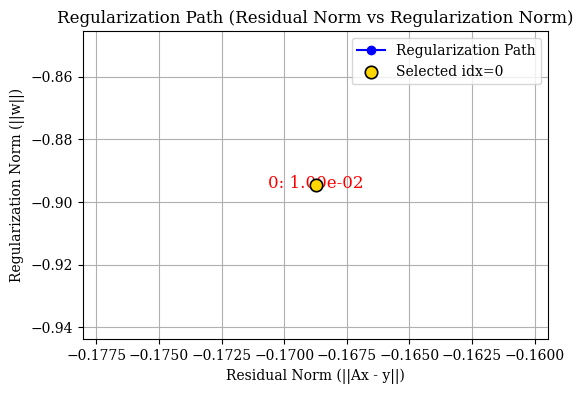

Training error at iteration 0 :
Generalization error at iteration 0 :


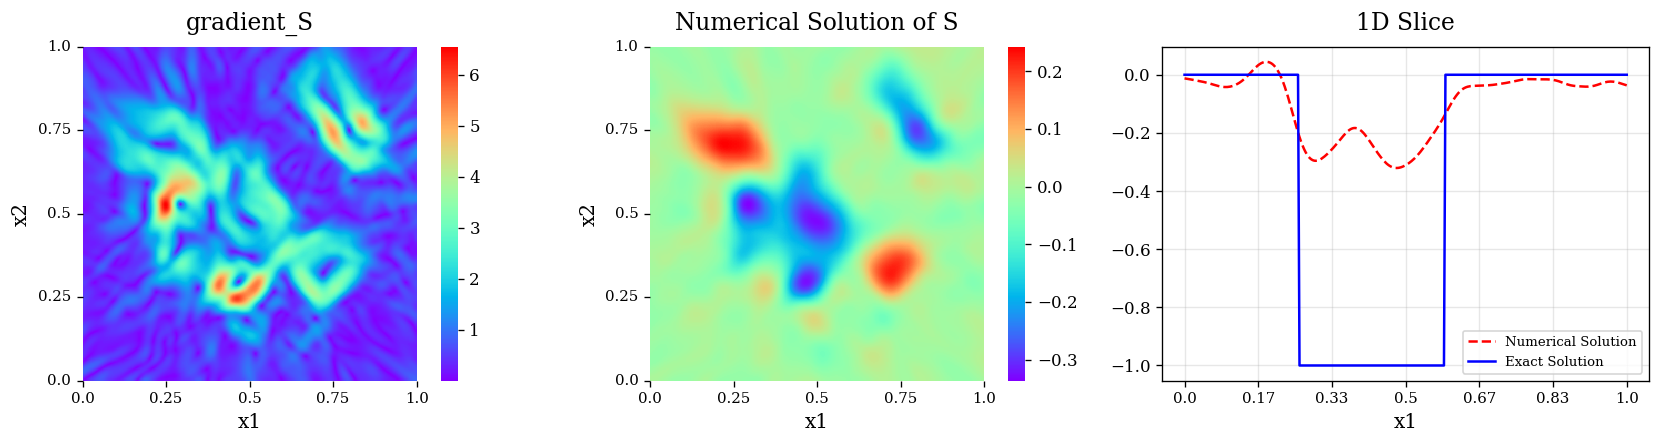

S_l_inf= 2.5395181463246774 S_L_2= 0.3357826472609898 S_l_2= 0.8245630379222222
Adaptive mesh refinement at iteration 0 ...


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


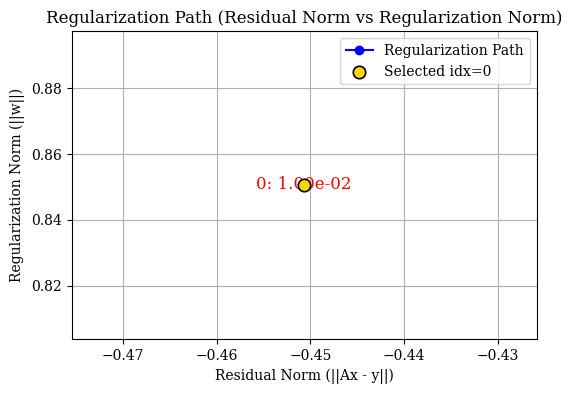

Training error at iteration 1 :
Generalization error at iteration 1 :


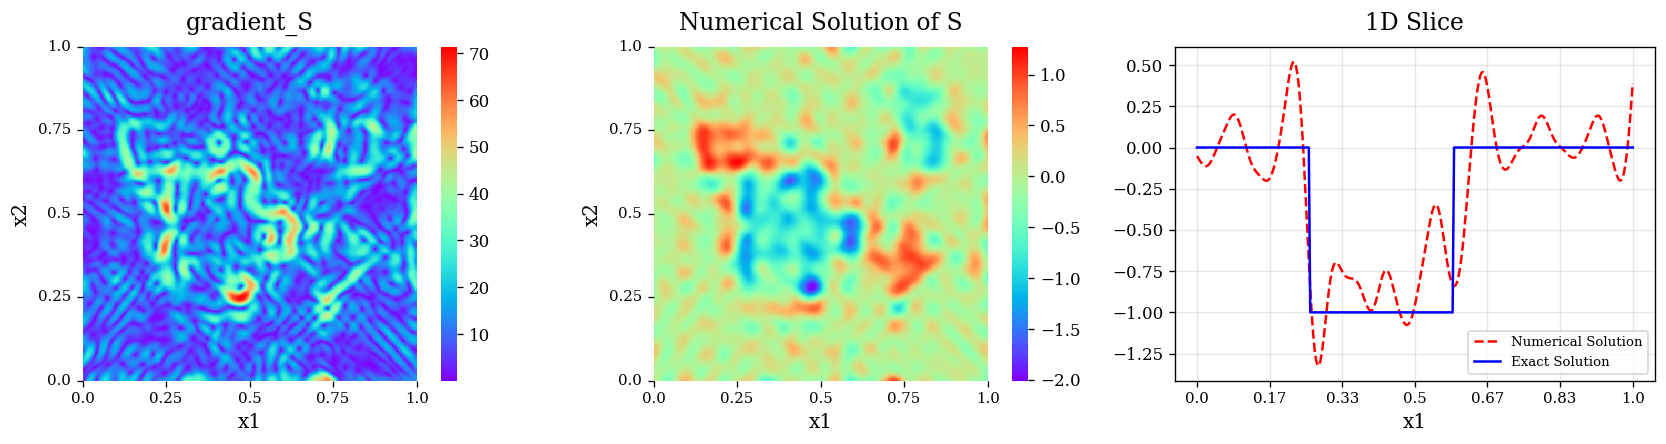

S_l_inf= 3.009585350143454 S_L_2= 0.2572265508169779 S_l_2= 0.6316571386461377
Adaptive mesh refinement at iteration 1 ...


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


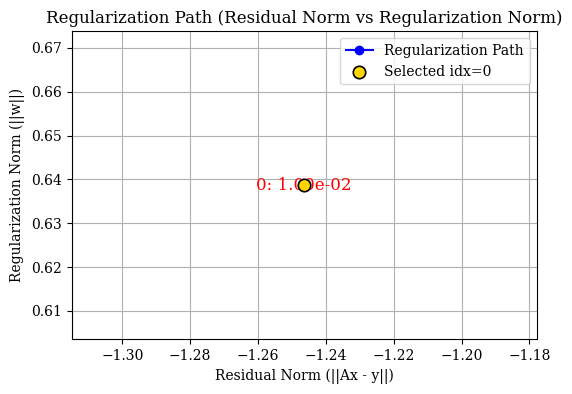

Training error at iteration 2 :
Generalization error at iteration 2 :


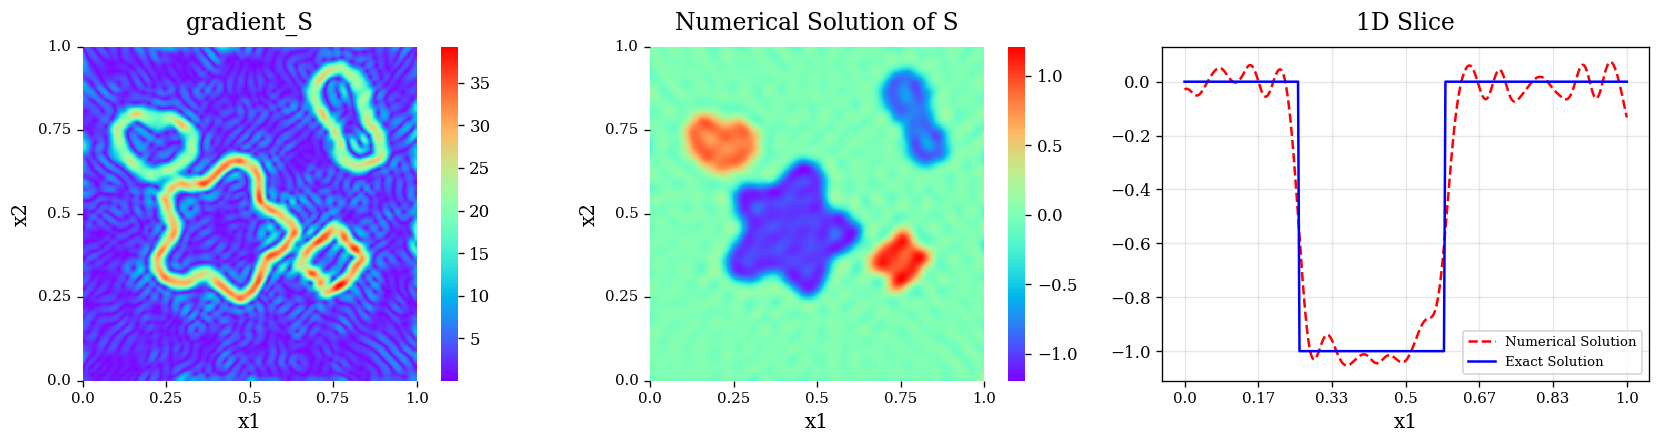

S_l_inf= 1.705746647341924 S_L_2= 0.10283154481883426 S_l_2= 0.2525177869723225
Adaptive mesh refinement at iteration 2 ...


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


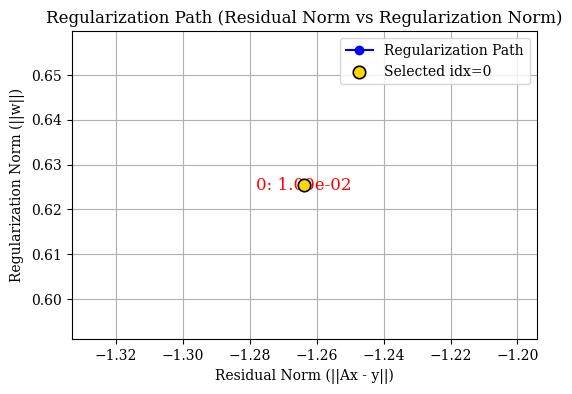

Training error at iteration 3 :
Generalization error at iteration 3 :


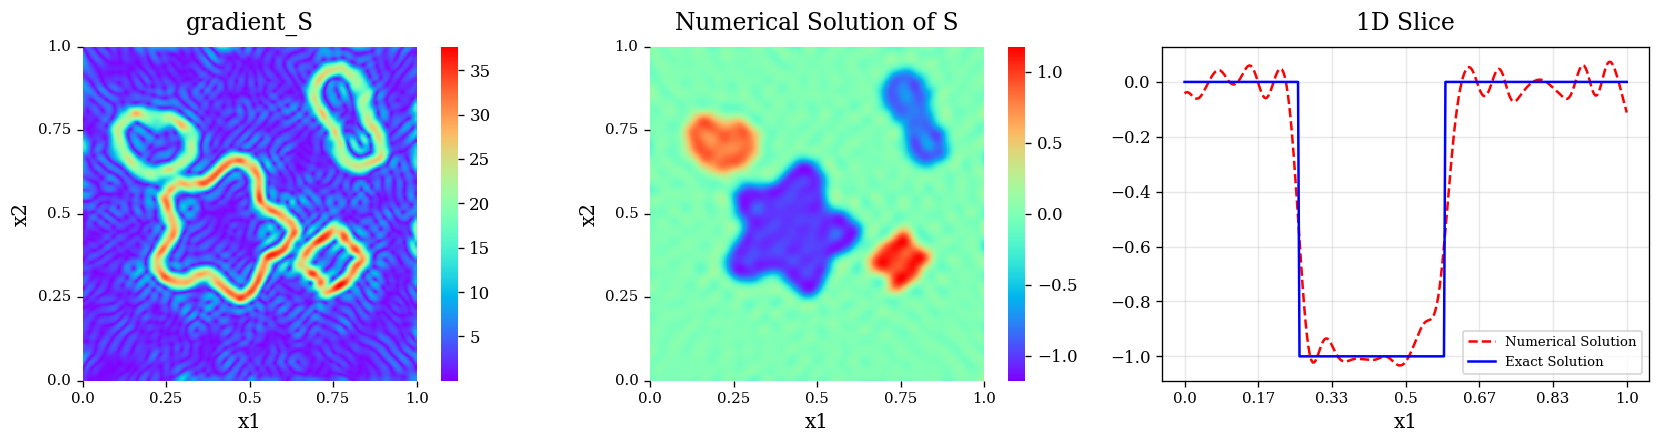

S_l_inf= 1.6773731131530014 S_L_2= 0.10199433108779873 S_l_2= 0.25046188711244594
Adaptive mesh refinement at iteration 3 ...


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


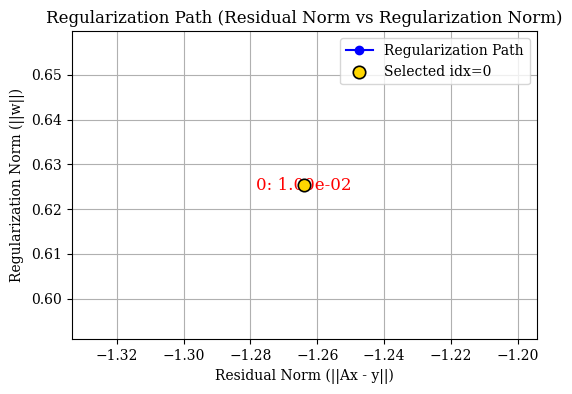

Training error at iteration 4 :
Generalization error at iteration 4 :


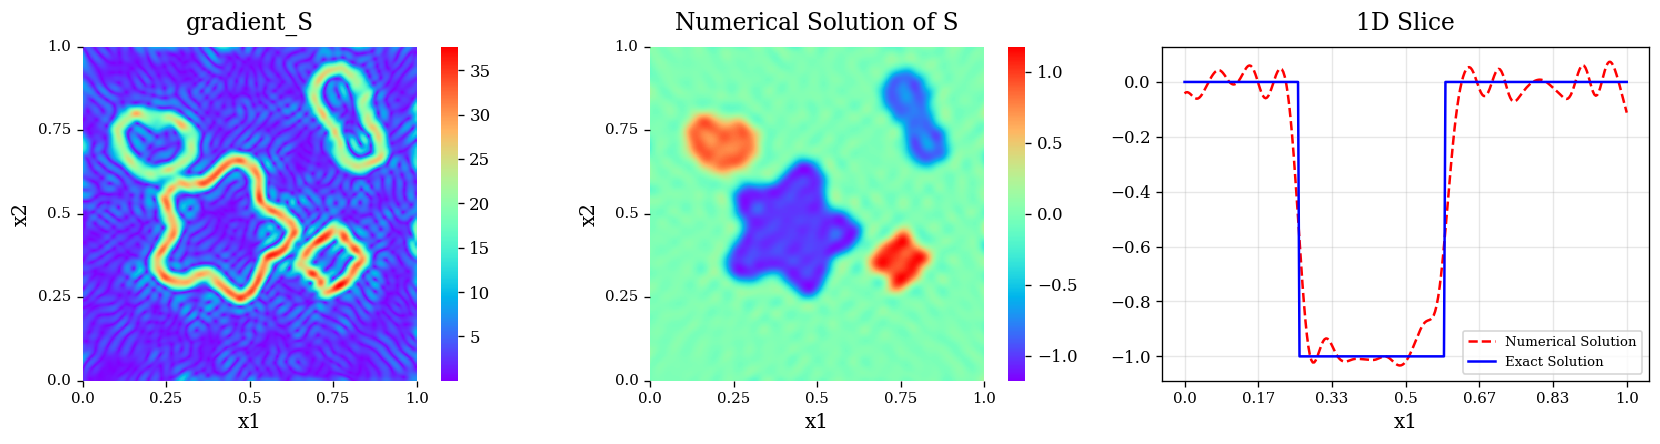

S_l_inf= 1.6772270395975193 S_L_2= 0.101995964844757 S_l_2= 0.25046589903983923
Stop at iteration 4


In [24]:
main._maybe_visualize = lambda *args, **kwargs: None  # Suppress the default AMR summary panel in this notebook.

iter_int= 5
Ix,Iy=4,4  # Number of grid cells in the x direction
delta=10**(-3)
nx=3
lamb_regu=np.logspace(-2,-1,1)
Qx,Qy=150,150
max_level=4
current_maxiter=1
af="Tanh"
Shape=[]
refine_threshold_S=1/100
refine_threshold_grad=1/300
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_l2,S_num_store=main.ada_int(iter_int,delta,cells,nx,model_tanh,M,af,Shape,[],kk,F,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,composite_source,points_b,lamb_regu,Qx,Qy,device,cupy_device,refine_threshold_S,refine_threshold_grad,current_maxiter,max_level)


DBSCAN eps = 0.016667 (5.000000 * h, h = 0.003333)
Number of detected clusters: 7
Number of retained clusters: 4
  CV of S_num: 0.203
Cluster 0: AR=1.22
  Res_Rect=0.111343 vs Res_Ellip=0.067531
  center=(0.2120, 0.7133)
  -> Decision: general (Sigmoid)
  CV of S_num: 0.259
Cluster 1: AR=1.02
  Res_Rect=0.193768 vs Res_Ellip=0.121102
  center=(0.4195, 0.4489)
  -> Decision: general (Sigmoid)
  CV of S_num: 0.273
Cluster 2: AR=1.02
  Res_Rect=0.182290 vs Res_Ellip=0.110238
  center=(0.7486, 0.3589)
  -> Decision: general (Sigmoid)
  CV of S_num: 0.212
Cluster 3: AR=1.44
  Res_Rect=0.206513 vs Res_Ellip=0.215246
  center=(0.7965, 0.7891)
  -> Decision: general (Sigmoid)


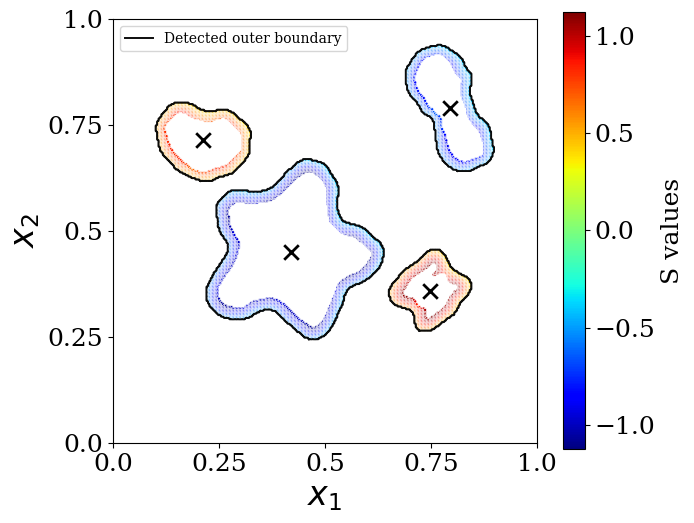

LaTeX table rows:
{\emph{Ex}} & Cluster $k$ & $\boldsymbol{c}_k$ & $r_k$ or $\boldsymbol{L}_k$ & $\mathcal{E}_{\mathrm{rect}}^{(k)}$ & $\mathcal{E}_{\mathrm{ellip}}^{(k)}$ & $\mathrm{AR}_k$ & $\mathrm{CV}_k$ & $\mathcal{T}_k$ & $\sigma_k$ \\
\multirow{4}{*}{Ex 4.7} & 1 & (2.12e-01, 7.13e-01) & - & 0.1113 & 0.0675 & 1.22 & 0.203 & \textbf{general} & Sigmoid \\
 & 2 & (4.20e-01, 4.49e-01) & - & 0.1938 & 0.1211 & 1.02 & 0.259 & \textbf{general} & Sigmoid \\
 & 3 & (7.49e-01, 3.59e-01) & - & 0.1823 & 0.1102 & 1.02 & 0.273 & \textbf{general} & Sigmoid \\
 & 4 & (7.96e-01, 7.89e-01) & - & 0.2065 & 0.2152 & 1.44 & 0.212 & \textbf{general} & Sigmoid \\


['{\\emph{Ex}} & Cluster $k$ & $\\boldsymbol{c}_k$ & $r_k$ or $\\boldsymbol{L}_k$ & $\\mathcal{E}_{\\mathrm{rect}}^{(k)}$ & $\\mathcal{E}_{\\mathrm{ellip}}^{(k)}$ & $\\mathrm{AR}_k$ & $\\mathrm{CV}_k$ & $\\mathcal{T}_k$ & $\\sigma_k$ \\\\',
 '\\multirow{4}{*}{Ex 4.7} & 1 & (2.12e-01, 7.13e-01) & - & 0.1113 & 0.0675 & 1.22 & 0.203 & \\textbf{general} & Sigmoid \\\\',
 ' & 2 & (4.20e-01, 4.49e-01) & - & 0.1938 & 0.1211 & 1.02 & 0.259 & \\textbf{general} & Sigmoid \\\\',
 ' & 3 & (7.49e-01, 3.59e-01) & - & 0.1823 & 0.1102 & 1.02 & 0.273 & \\textbf{general} & Sigmoid \\\\',
 ' & 4 & (7.96e-01, 7.89e-01) & - & 0.2065 & 0.2152 & 1.44 & 0.212 & \\textbf{general} & Sigmoid \\\\']

In [25]:
from importlib import reload
import bound_detect
reload(bound_detect)
x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)
eps_cluster=5
mini_samples=20
para_abs=3
para_grad=3
results=bound_detect.detect_shape(
    g_S, X.T, Y.T,
    tau_x_min, tau_x_max, tau_y_min, tau_y_max,
    para_abs, para_grad, eps_cluster, mini_samples,
    S_num_store[-1],
    output_directory="./noise=5%",
    output_filename="plot.png",
    min_cluster_size=200,
    keep_top_k=None,
    fit_rotation=False,
    show_general_boundary=True,
)

print("LaTeX table rows:")
bound_detect.print_latex_result_rows(results, example_name="Ex 4.7", include_header=True)

In [26]:
results

[{'cluster_id': 0,
  'shape': 'general',
  'params': {'center': array([0.21198552, 0.7133267 ])},
  'profile': 'Sigmoid',
  'boundary_points': array([[0.20619333, 0.61744   ],
         [0.20577333, 0.61786   ],
         [0.20535333, 0.61786   ],
         ...,
         [0.20745333, 0.61786   ],
         [0.20703333, 0.61744   ],
         [0.20661333, 0.61744   ]]),
  'diagnostics': {'Lx': 0.22000000000000003,
   'Ly': 0.18000000000000005,
   'aspect_ratio': 1.222222222222222,
   'res_rect': 0.11134335460305866,
   'res_ellip': 0.0675307512749482,
   'residual_threshold': 0.05,
   'tori_ratio': 0.41187460223752514,
   'r_mean': 0.08836679494450451,
   'min_dist_to_center': 0.04690746033933614,
   'max_dist_to_center': 0.11388772234196888,
   'dist_05': 0.06119189836644621,
   'dist_95': 0.10847700499216201},
  'aspect_ratio': 1.222222222222222,
  'res_rect': 0.11134335460305866,
  'res_ellip': 0.0675307512749482,
  'Lx': 0.22000000000000003,
  'Ly': 0.18000000000000005,
  'tori_ratio': 0

In [27]:
# Automatically assign the detected clusters to basis families.
reload(bound_detect)
min_general_boundary_points = 200
basis_family_split = bound_detect.split_detected_basis_families(
    results,
    min_general_boundary_points=min_general_boundary_points,
)

cluster_lookup = basis_family_split["cluster_lookup"]
general_results = basis_family_split["general_results"]
regular_results = basis_family_split["regular_results"]
general_cluster_ids = basis_family_split["general_cluster_ids"]
regular_result = basis_family_split["regular_result"]
regular_cluster_id = basis_family_split["regular_cluster_id"]
regular_shape_detected = basis_family_split["regular_shape_detected"]
regular_shape = basis_family_split["regular_shape"]
general_boundaries = basis_family_split["general_boundaries"]
regular_boundary = basis_family_split["regular_boundary"]
regular_params = regular_result["params"] if regular_result is not None else {}
regular_center = np.asarray(regular_params["center"]) if regular_result is not None else None

general cluster_id=0, center=(0.2120, 0.7133), boundary_points=1674
general cluster_id=1, center=(0.4195, 0.4489), boundary_points=2393
general cluster_id=2, center=(0.7486, 0.3589), boundary_points=1650
general cluster_id=3, center=(0.7965, 0.7891), boundary_points=1706


In [ ]:
reload(visual)
reload(bound_detect)

h = max((tau_x_max - tau_x_min) / 300.0, (tau_y_max - tau_y_min) / 300.0)
alpha = 5e-3
M_sig = int(globals().get("M_sig", 800))
shrink_distances = np.array([-6 * h, -3 * h])

boundary_noise_outputs = visual.plot_boundary_shrinking_and_noise_centers(
    general_results,
    boundaries=general_boundaries,
    g_S=g_S,
    tau_x_min=tau_x_min,
    tau_x_max=tau_x_max,
    tau_y_min=tau_y_min,
    tau_y_max=tau_y_max,
    h=h,
    alpha=alpha,
    M_sig=M_sig,
    shrink_distances=shrink_distances,
    noise_scale_range=(-10.0, 10.0),
    n_resample_shrink=1200,
    n_resample_noise=800,
    output_directory=".",
    output_filename="./noise=5%/general_cluster_boundary_shrinking_and_noise.png",
)

general_offset_curves = boundary_noise_outputs["offset_curves"]
general_noise_centers_by_cluster = boundary_noise_outputs["noise_centers_by_cluster"]
general_candidate_centers_by_cluster = boundary_noise_outputs["candidate_centers_by_cluster"]
general_noise_scale_factors_by_cluster = boundary_noise_outputs["noise_scale_factors_by_cluster"]

In [29]:
M_sig = 1000
general_basis_counts = [M_sig] * len(general_results)
M_noise = 800
print("general_basis_counts:", general_basis_counts)
print("M_noise:", M_noise)


general_basis_counts: [1000, 1000, 1000, 1000]
M_noise: 800


In [30]:
# Build one signed-distance matrix per general cluster.
scale_factors_by_cluster = {}
scale_curves_by_cluster = {}
sign_distances_train_by_cluster = {}

for item, m_sig_i in zip(general_results, general_basis_counts):
    cluster_id = int(item["cluster_id"])
    boundary = general_boundaries[cluster_id]
    center = np.asarray(item["params"]["center"], dtype=float)
    scale_factor_i = np.random.uniform(-10 * h, 10*h, size=int(m_sig_i))
    scale_curves_i, sign_distances_i = bound_detect.generate_signed_distance(
        g_store[-1],
        boundary,
        alpha,
        scale_factor_i,
        int(m_sig_i),
        center=center,
        center_oriented=True,
    )
    scale_factors_by_cluster[cluster_id] = scale_factor_i
    scale_curves_by_cluster[cluster_id] = scale_curves_i
    sign_distances_train_by_cluster[cluster_id] = sign_distances_i
    print(f"general cluster_id={cluster_id}, basis_count={int(m_sig_i)}, sign_distance_shape={sign_distances_i.shape}")

sign_distances_t = [sign_distances_train_by_cluster[int(item["cluster_id"])] for item in general_results]
print("sign_distances_t shapes:", [arr.shape for arr in sign_distances_t])


general cluster_id=0, basis_count=1000, sign_distance_shape=(7380, 1000)
general cluster_id=1, basis_count=1000, sign_distance_shape=(7380, 1000)
general cluster_id=2, basis_count=1000, sign_distance_shape=(7380, 1000)
general cluster_id=3, basis_count=1000, sign_distance_shape=(7380, 1000)
sign_distances_t shapes: [(7380, 1000), (7380, 1000), (7380, 1000), (7380, 1000)]


In [31]:
K_min=1000
K_max=30000
R_m=20
modelsig_list = []
for item, m_sig_i in zip(general_results, general_basis_counts):
    modelsig_i = net_2d.local_rep(
        in_features=2,
        out_features=1,
        hidden_layers=1,
        M=int(m_sig_i),
        M_noise=[],
        b1_noise=[],
        b2_noise=[],
        x_max=1,
        x_min=0,
        y_max=1,
        y_min=0,
        r_min=[],
        r_max=[],
        b1_min=[],
        b1_max=[],
        b2_min=[],
        b2_max=[],
        width_min=[],
        width_max=[],
        height_min=[],
        height_max=[],
        peak_min=[],
        peak_max=[],
        v_min=[],
        v_max=[],
        K_min=K_min,
        K_max=K_max,
        R_m_for_init=R_m,
        af="sigmoid",
        Shape="general",
        device=device,
    ).to(device)
    modelsig_list.append(modelsig_i)

modelnoise_list = []
selected_noise_centers_by_cluster = {}
for item in general_results:
    cluster_id = int(item["cluster_id"])
    noise_center_pool = general_noise_centers_by_cluster[cluster_id]
    if len(noise_center_pool) >= M_noise:
        noise_idx = np.random.choice(len(noise_center_pool), size=M_noise, replace=False)
    else:
        noise_idx = np.random.choice(len(noise_center_pool), size=M_noise, replace=True)
    noise_centers = noise_center_pool[noise_idx]
    selected_noise_centers_by_cluster[cluster_id] = noise_centers
    b1_noise = noise_centers[:, 0]
    b2_noise = noise_centers[:, 1]
    modelnoise_i = net_2d.local_rep(
        in_features=2,
        out_features=1,
        hidden_layers=1,
        M=1,
        M_noise=b1_noise.shape[0],
        b1_noise=-b1_noise,
        b2_noise=-b2_noise,
        x_max=1,
        x_min=0,
        y_max=1,
        y_min=0,
        r_min=0,
        r_max=10 * h,
        b1_min=0,
        b1_max=1,
        b2_min=0,
        b2_max=1,
        width_min=[],
        width_max=[],
        height_min=[],
        height_max=[],
        peak_min=[],
        peak_max=[],
        v_min=[],
        v_max=[],
        K_min=K_min,
        K_max=K_max,
        R_m_for_init=R_m,
        af="sigmoid",
        Shape="noise",
        device=device,
    ).to(device)
    modelnoise_list.append(modelnoise_i)

extra_models = modelsig_list  + modelnoise_list
extra_shapes = ["general"] * len(modelsig_list) + ["noise"] * len(modelnoise_list)
basis_sizes = [getattr(model, "M", 0) if shape != "noise" else getattr(model, "M_noise", 0) for model, shape in zip(extra_models, extra_shapes)]
print("extra_shapes:", extra_shapes)
print("basis sizes:", basis_sizes)


extra_shapes: ['general', 'general', 'general', 'general', 'noise', 'noise', 'noise', 'noise']
basis sizes: [1000, 1000, 1000, 1000, 800, 800, 800, 800]


In [32]:
reload(matrix_assemble)
sum_mat,all_g_p1,all_g_n,cells_copy1 = matrix_assemble.mat_assemble2(
    cells_store[-1],
    model_tanh,
    extra_models,
    [],
    [],
    "mix_general",
    extra_shapes,
    [],
    sign_distances_t,
    kk,
    0,
    points_b,
    device,
    cupy_device,
)
expected_basis_dim = model_tanh.M + sum(getattr(model, "M", 0) if shape != "noise" else getattr(model, "M_noise", 0) for model, shape in zip(extra_models, extra_shapes))
print("expected basis dim:", expected_basis_dim)
print("sum_mat shape:", sum_mat.shape)


expected basis dim: 8800
sum_mat shape: (8320, 8800)


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


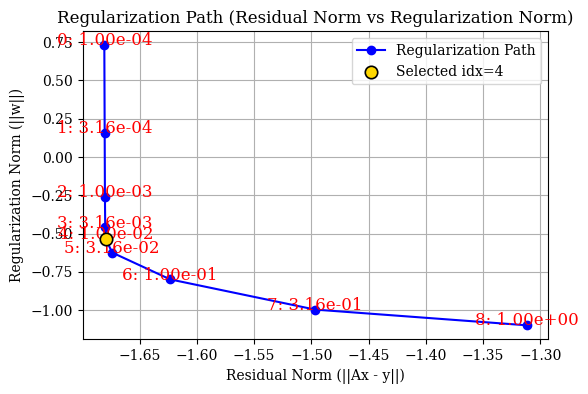

In [33]:
lamb_regu=np.logspace(-4,0,9,endpoint=True)
res,reg_norm,w_store=inverse_solver.L_curve(sum_mat,F,[],[],[],lamb_regu,"linear",device,cupy_device)

In [34]:
sample_s = error_general_2d.test_p(Qx,Qy,tau_x_min,tau_x_max,tau_y_min,tau_y_max)
sign_distances_test_by_cluster = {}
for item in general_results:
    cluster_id = int(item["cluster_id"])
    boundary = general_boundaries[cluster_id]
    center = np.asarray(item["params"]["center"], dtype=float)
    scale_factor_i = scale_factors_by_cluster[cluster_id]
    _, sign_distances_i = bound_detect.generate_signed_distance(
        sample_s,
        boundary,
        alpha,
        scale_factor_i,
        len(scale_factor_i),
        center=center,
        center_oriented=True,
    )
    sign_distances_test_by_cluster[cluster_id] = sign_distances_i

sign_distances_test = [sign_distances_test_by_cluster[int(item["cluster_id"])] for item in general_results]
print("sign_distances_test shapes:", [arr.shape for arr in sign_distances_test])


sign_distances_test shapes: [(90601, 1000), (90601, 1000), (90601, 1000), (90601, 1000)]


L-curve corner index: 4
Curvature-centered lambda window:
  idx=3, lambda=3.162278e-03, curvature=4.022166e-02
  idx=4, lambda=1.000000e-02, curvature=8.920146e-01 <== center
  idx=5, lambda=3.162278e-02, curvature=7.494672e-01
candidate idx: [3 4 5]
candidate lambda: [0.00316228 0.01       0.03162278]


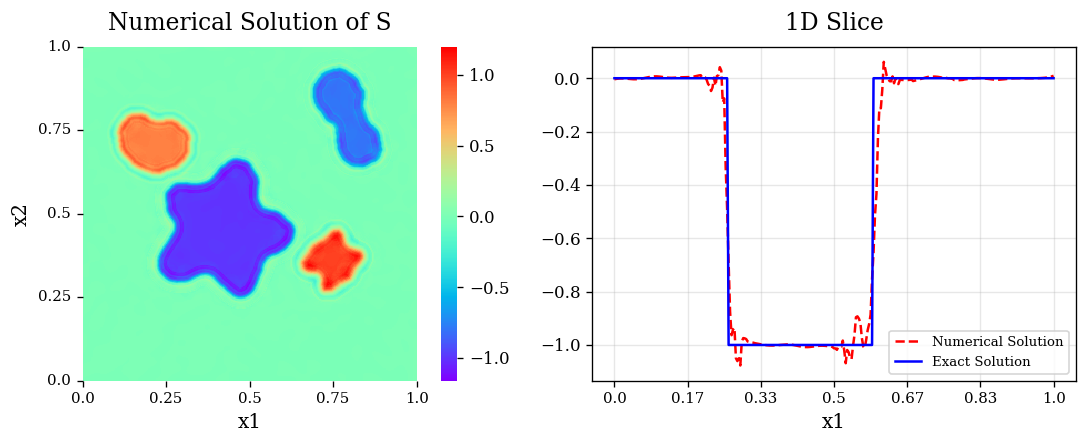

S_l_inf= 1.9673487909339282 S_L_2= 0.07262923844015547 S_l_2= 0.17835163901023177
candidate idx=3, lamb=1e-05, S_l_inf=1.9673487909339282, S_l_2=0.17835163901023177


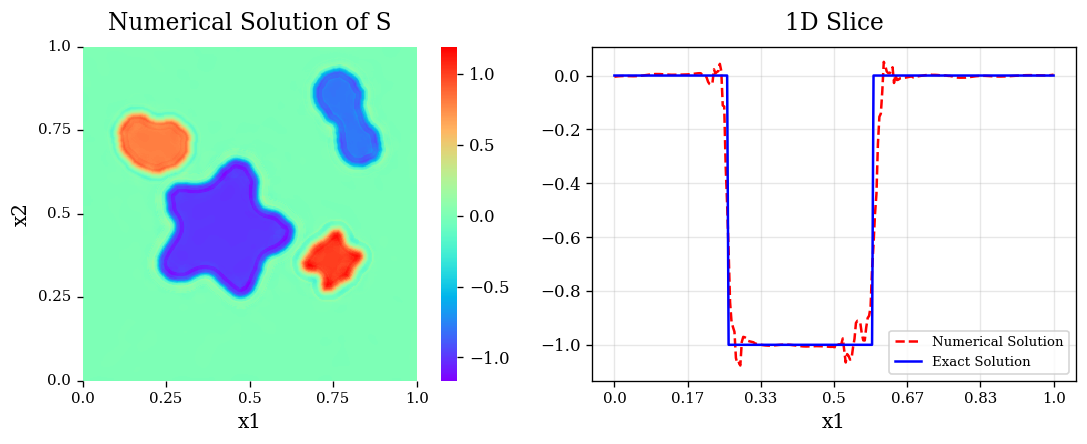

S_l_inf= 1.9033455488347686 S_L_2= 0.07456532307449829 S_l_2= 0.18310597590283303
candidate idx=4, lamb=0.0001, S_l_inf=1.9033455488347686, S_l_2=0.18310597590283303


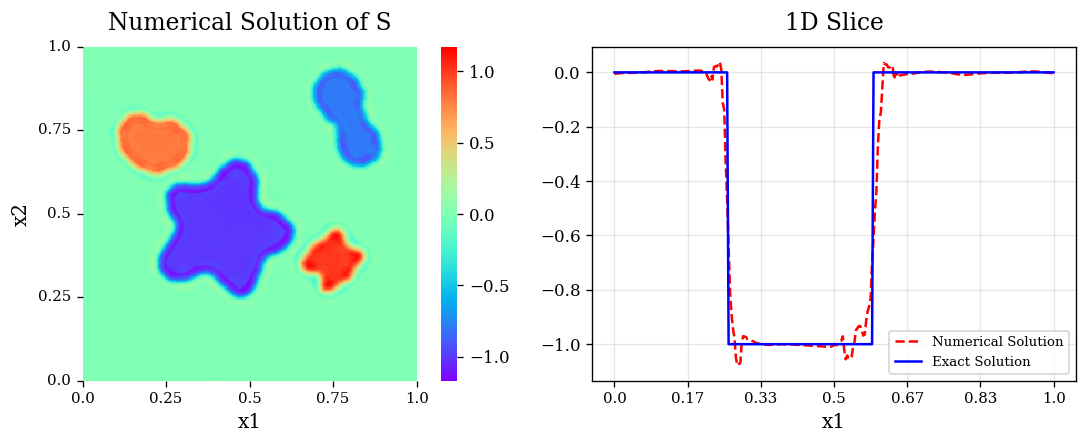

S_l_inf= 1.860596225650652 S_L_2= 0.07581606416566719 S_l_2= 0.1861773522297544
candidate idx=5, lamb=0.0009999999999999998, S_l_inf=1.860596225650652, S_l_2=0.1861773522297544


In [35]:
reload(inverse_solver)
window_idx, window_lambda, window_w, curvature = inverse_solver.lambda_window_by_curvature(
    lamb_regu, res, reg_norm, radius=1, w_store=w_store
)
print('candidate idx:', window_idx)
print('candidate lambda:', window_lambda)
window_results = []
for local_i, cand_idx in enumerate(window_idx):
    cand_lamb = window_lambda[local_i]**2
    cand_w = window_w[:, local_i]
    result_tuple = error_general_2d.test(
        model_tanh,
        extra_models,
        [],
        [],
        sample_s,
        cand_w,
        "mix_general",
        extra_shapes,
        [],
        sign_distances_test,
        True,
        True,
        tau_x_min,
        tau_x_max,
        tau_y_min,
        tau_y_max,
        x_left,
        x_right,
        y_below,
        y_upper,
        center_true,
        r_true,
        composite_source,
        0.5,
        0,
        device,
    )
    window_results.append({
        'idx': int(cand_idx),
        'lambda': cand_lamb,
        'w': cand_w,
        'result': result_tuple,
    })
    print(
        f"candidate idx={int(cand_idx)}, lamb={cand_lamb}, "
        f"S_l_inf={result_tuple[2]}, S_l_2={result_tuple[3]}"
    )


In [36]:
pick = 0
picked = window_results[pick]
idx = picked['idx']
lamb = picked['lambda']
picked_w = picked['w']
S_test_num,S_test_true,S_l_inf1,S_l_21,g_SS = picked['result']
print('picked idx:', idx)
print('lamb:', lamb)


picked idx: 3
lamb: 1e-05


In [37]:
if "results" in globals():
    boundary_payload = {
        f"cluster_{int(item['cluster_id'])}": np.asarray(item["boundary_points"], dtype=float)
        for item in results
        if isinstance(item, dict) and "boundary_points" in item
    }
    if boundary_payload:
        np.savez("./noise=5%/detected_boundaries.npz", **boundary_payload)

np.save("./noise=5%/general_w_store.npy", w_store)
for cluster_id, arr in sign_distances_train_by_cluster.items():
    np.save(f"./noise=5%/general_cluster_{cluster_id}_sign_distances_train.npy", arr)
for cluster_id, arr in sign_distances_test_by_cluster.items():
    np.save(f".//noise=5%/general_cluster_{cluster_id}_sign_distances_test.npy", arr)
torch.save(model_tanh.state_dict(), "./noise=5%/general_model_tanh.pth")
for local_idx, model in enumerate(modelsig_list):
    torch.save(model.state_dict(), f"./noise=5%/general_model_sig_{local_idx}.pth")
for local_idx, model in enumerate(modelnoise_list):
    torch.save(model.state_dict(), f"./noise=5%/noise_model_sig_{local_idx}.pth")
np.save("./noise=5%/S_num.npy",S_test_num)


In [38]:
# Save cells_store
import pickle
import pickle
with open("./noise=5%/cells_store_last.pkl", "wb") as f:
    pickle.dump(cells_store[-1], f)
    

In [39]:
n_integral=len(cells_store[-1])*9
print('n_integral:',n_integral)
print('S_l2[-1]:',S_l2[-1])
print('lamb_regu:',lamb)
print('S_l21:',S_l_21)

n_integral: 7380
S_l2[-1]: 0.25046589903983923
lamb_regu: 1e-05
S_l21: 0.17835163901023177
